# Customer Churn Analysis & Prediction
This notebook walks through the data generation, exploratory data analysis, model training, and performance evaluation for predicting customer churn.

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score, 
    classification_report, 
    confusion_matrix, 
    ConfusionMatrixDisplay, 
    roc_curve, 
    auc
)

sns.set_theme(style="whitegrid")

## 1. Data Generation

In [4]:
np.random.seed(42)
data_size = 1500

tenure = np.random.randint(1, 72, size=data_size)
monthly_charges = np.random.uniform(20, 120, size=data_size)
contract = np.random.choice(['Month-to-month', 'One year', 'Two year'], size=data_size, p=[0.5, 0.3, 0.2])

logit = (monthly_charges * 0.04) - (tenure * 0.08) + (contract == 'Month-to-month') * 1.5 - 1.0
probability = 1 / (1 + np.exp(-logit))
churn = np.random.binomial(1, probability)

df = pd.DataFrame({
    'tenure': tenure,
    'MonthlyCharges': monthly_charges,
    'Contract': contract,
    'Churn': churn
})

df.head()

,tenure,MonthlyCharges,Contract,Churn
0,52,40.357828,One year,0
1,15,104.045241,Month-to-month,1
2,61,37.419334,Month-to-month,0
3,21,116.078055,Month-to-month,1
4,24,61.590737,Month-to-month,1


## 2. Exploratory Data Analysis (EDA)

C:\Users\giaky\AppData\Local\Temp\ipykernel_10948\288946235.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='Churn', y='tenure', ax=axes[0], palette='Set2')
C:\Users\giaky\AppData\Local\Temp\ipykernel_10948\288946235.py:5: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator. Otherwise, ticks may be mislabeled.
  axes[0].set_xticklabels(['Stayed (0)', 'Churned (1)'])
C:\Users\giaky\AppData\Local\Temp\ipykernel_10948\288946235.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='Churn', y='MonthlyCharges', ax=axes[1], palette='Set2')
C:\Users\giaky\AppData\Local\Temp\ipykernel_10948\288946235

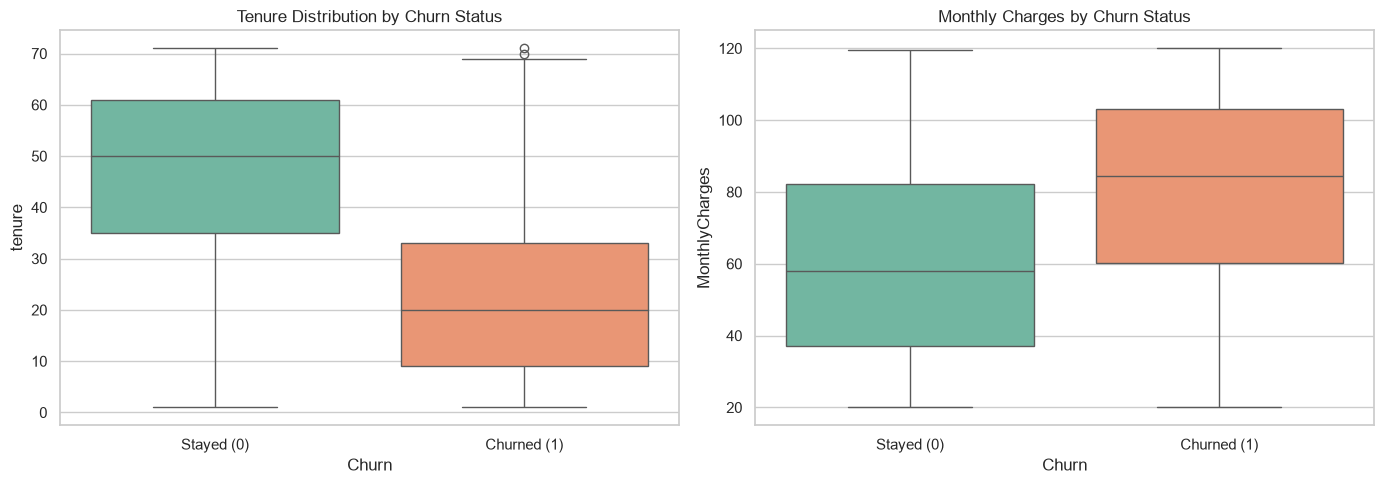

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.boxplot(data=df, x='Churn', y='tenure', ax=axes[0], palette='Set2')
axes[0].set_title('Tenure Distribution by Churn Status')
axes[0].set_xticklabels(['Stayed (0)', 'Churned (1)'])

sns.boxplot(data=df, x='Churn', y='MonthlyCharges', ax=axes[1], palette='Set2')
axes[1].set_title('Monthly Charges by Churn Status')
axes[1].set_xticklabels(['Stayed (0)', 'Churned (1)'])

plt.tight_layout()
plt.show()

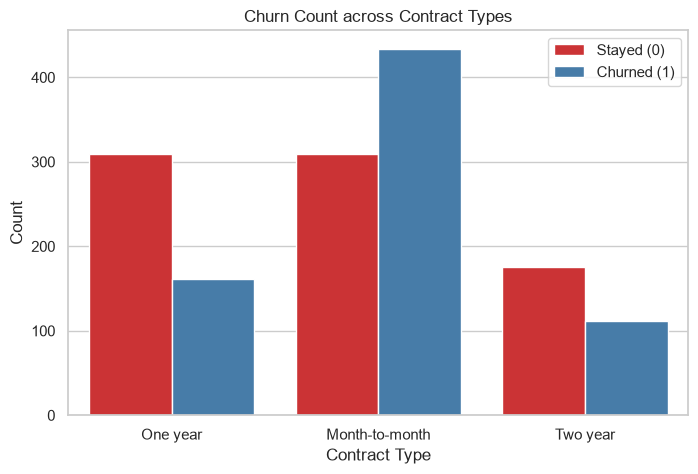

In [6]:
plt.figure(figsize=(8, 5))
sns.countplot(data=df, x='Contract', hue='Churn', palette='Set1')
plt.title('Churn Count across Contract Types')
plt.xlabel('Contract Type')
plt.ylabel('Count')
plt.legend(['Stayed (0)', 'Churned (1)'])
plt.show()

## 3. Data Preprocessing & Model Training

In [7]:
X = df.drop('Churn', axis=1)
y = df['Churn']

numeric_features = ['tenure', 'MonthlyCharges']
categorical_features = ['Contract']

preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), numeric_features),
        ('cat', OneHotEncoder(), categorical_features)
    ])

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

X_train_processed = preprocessor.fit_transform(X_train)
X_test_processed = preprocessor.transform(X_test)

model = LogisticRegression()
model.fit(X_train_processed, y_train)

print("Model successfully trained.")

Model successfully trained.


## 4. Evaluation & Plot Extraction

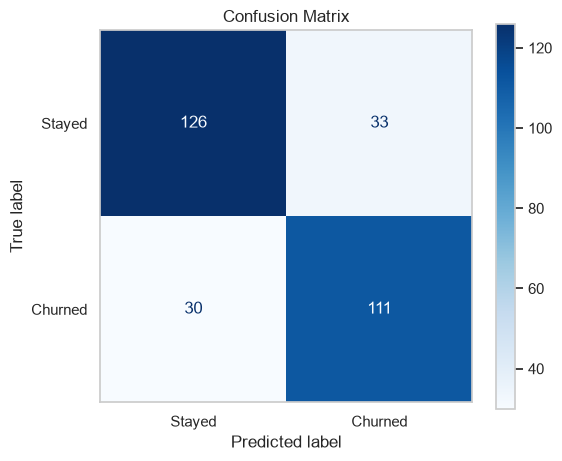

In [8]:
import os
os.makedirs('images', exist_ok=True)

y_pred = model.predict(X_test_processed)
y_pred_proba = model.predict_proba(X_test_processed)[:, 1]

cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Stayed', 'Churned'])

fig, ax = plt.subplots(figsize=(6, 5))
disp.plot(cmap='Blues', ax=ax)
ax.set_title('Confusion Matrix')
plt.grid(False)

plt.savefig('images/confusion_matrix.png', dpi=300, bbox_inches='tight')
plt.show()

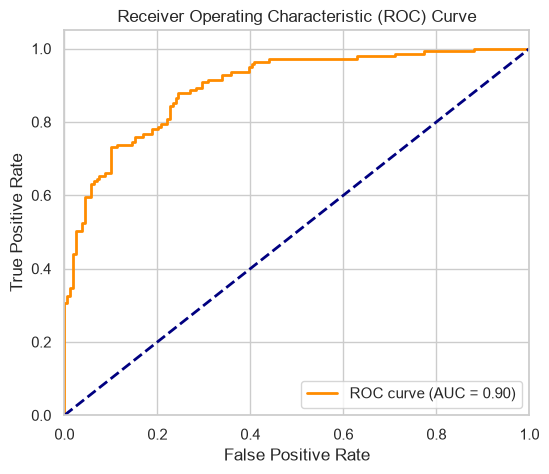

In [9]:
fpr, tpr, _ = roc_curve(y_test, y_pred_proba)
roc_auc = auc(fpr, tpr)

plt.figure(figsize=(6, 5))
plt.plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC curve (AUC = {roc_auc:.2f})')
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic (ROC) Curve')
plt.legend(loc="lower right")

plt.savefig('images/roc_curve.png', dpi=300, bbox_inches='tight')
plt.show()

C:\Users\giaky\AppData\Local\Temp\ipykernel_10948\3065328586.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=coefficients, y=feature_names, palette='coolwarm')


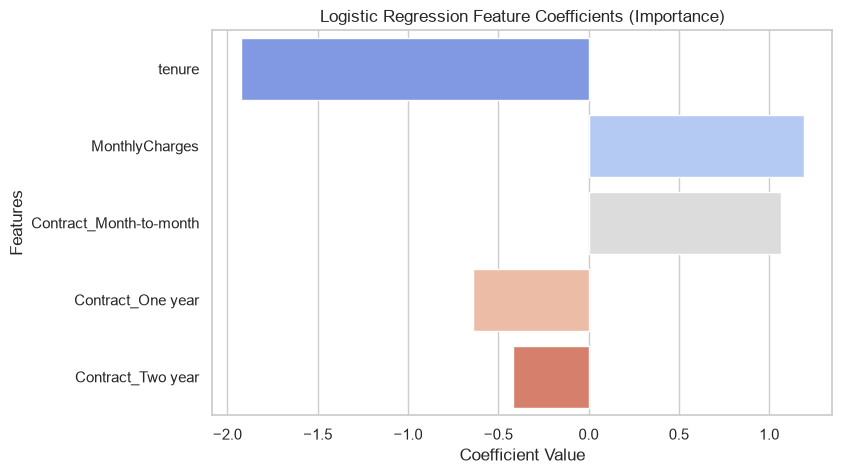

In [10]:
cat_encoder = preprocessor.named_transformers_['cat']
encoded_cat_features = list(cat_encoder.get_feature_names_out(['Contract']))
feature_names = numeric_features + encoded_cat_features

coefficients = model.coef_[0]

plt.figure(figsize=(8, 5))
sns.barplot(x=coefficients, y=feature_names, palette='coolwarm')
plt.title('Logistic Regression Feature Coefficients (Importance)')
plt.xlabel('Coefficient Value')
plt.ylabel('Features')

plt.savefig('images/feature_importance.png', dpi=300, bbox_inches='tight')
plt.show()

In [11]:
print(f"Model Accuracy: {accuracy_score(y_test, y_pred):.2f}\n")
print("Classification Report:\n", classification_report(y_test, y_pred))

Model Accuracy: 0.79

Classification Report:
               precision    recall  f1-score   support

           0       0.81      0.79      0.80       159
           1       0.77      0.79      0.78       141

    accuracy                           0.79       300
   macro avg       0.79      0.79      0.79       300
weighted avg       0.79      0.79      0.79       300

